<a href="https://colab.research.google.com/github/annandabispo/air-quality-data-analysis/blob/main/Analise_Qualidade_Ar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## Análise Exploratória da Qualidade do Ar em Milão, Itália

- Autora: Annanda Bispo

Este projeto apresenta uma análise exploratória de dados de qualidade do ar coletados em uma área urbana de Milão, Itália, entre março de 2004 e fevereiro de 2005.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://drive.google.com/uc?id=1S1PHWBzvDCJR66KF1OCANv0n0JdRUshi"

df = pd.read_csv(
    url,
    sep=';',
    decimal=','
)

## 1. Objetivo

Analisar os níveis de poluição do ar registrados no conjunto de dados e identificar padrões, correlações e possíveis relações entre poluentes atmosféricos e variáveis climáticas.


## 2. Entendimento dos Dados
O dataset contém medições de qualidade do ar coletadas em Milão, Itália, entre março de 2004 e fevereiro de 2005.

Entre as variáveis de interesse estão:

 - `CO(GT)`: concentração de monóxido de carbono;
- `NOx(GT)`: concentração de óxidos de nitrogênio;
- `NO2(GT)`: concentração de dióxido de nitrogênio;
- `T`: temperatura;
- `RH`: umidade relativa;
- `AH`: umidade absoluta;
variáveis
- `PT08`: respostas de sensores químicos presentes no conjunto de dados.


In [3]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [4]:
print("Dimensão inicial:", df.shape)
df.info()


Dimensão inicial: (9471, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(

In [5]:
#mostrar variaveis
tipos = []

for coluna in df.columns:

    tipo = df[coluna].dtype

    if tipo == "object":
        tipos.append([coluna, "Texto"])

    elif tipo == "float64" or tipo == "int64":
        tipos.append([coluna, "Número"])

    elif "datetime" in str(tipo):
        tipos.append([coluna, "Data e Hora"])

tipos_df = pd.DataFrame(tipos, columns=["Variável", "Tipo"])

tipos_df

,Variável,Tipo
0,Date,Texto
1,Time,Texto
2,CO(GT),Número
3,PT08.S1(CO),Número
4,NMHC(GT),Número
5,C6H6(GT),Número
6,PT08.S2(NMHC),Número
7,NOx(GT),Número
8,PT08.S3(NOx),Número
9,NO2(GT),Número


### Hipóteses exploratórias

A análise busca investigar cinco hipóteses principais:

**H1 — Temperatura e poluição:** se temperaturas mais baixas estão associadas a maiores concentrações de poluentes atmosféricos.

**H2 — Umidade e poluição:** se níveis mais elevados de umidade estão associados a maiores concentrações de gases poluentes.

**H3 — Períodos frios e óxidos de nitrogênio:** se períodos de menor temperatura apresentam maiores concentrações de `NOx(GT)` e `NO2(GT)`.

**H4 — Padrões ao longo do dia:** se as concentrações de `CO(GT)`, `NOx(GT)` e `NO2(GT)` apresentam variações de acordo com o horário do dia.

**H5 — Relação entre poluentes:** se `NOx(GT)` e `NO2(GT)` apresentam associação positiva e comportamento semelhante ao longo do período analisado.

**H6 — Sensores e medições de referência:** as respostas dos sensores `PT08` apresentam associação com as concentrações de referência dos poluentes analisados

## 3. Inspeção Inicial


In [6]:

print("Quantidade de linhas e colunas:", df.shape)

print("\nValores faltantes por coluna:")
print(df.isnull().sum())

print("\nQuantidade total de valores faltantes explícitos:")
print(df.isnull().sum().sum())

print("\nQuantidade de linhas duplicadas na importação bruta:")
print(df.duplicated().sum())

Quantidade de linhas e colunas: (9471, 17)

Valores faltantes por coluna:
Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64

Quantidade total de valores faltantes explícitos:
20652

Quantidade de linhas duplicadas na importação bruta:
113


Além dos valores nulos explícitos, o dataset utiliza o valor -200 para representar medições ausentes ou inválidas.

Também existem duas colunas vazias geradas durante a importação (Unnamed: 15 e Unnamed: 16) e linhas sem informação temporal válida. Esses elementos serão tratados antes da análise.

## 4. Limpeza dos Dados

A limpeza será realizada na seguinte ordem:

1. remover colunas vazias;
2. substituir `-200` por `NaN`;
3. criar uma variável `Datetime`;
4. remover linhas sem data/hora válida;
5. ordenar cronologicamente;
6. remover duplicatas remanescentes;
7. preencher valores ausentes das variáveis numéricas com a média.


In [7]:
# 1. Remover colunas vazias
colunas_remover = ["Unnamed: 15", "Unnamed: 16"]
df = df.drop(
    columns=[col for col in colunas_remover if col in df.columns]
)

# 2. Substituir o marcador -200 por NaN
df = df.replace(-200, np.nan)

# 3. Criar uma variável temporal
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# 4. Remover registros sem data/hora válida
df = df.dropna(subset=["Datetime"])

# 5. Ordenar cronologicamente
df = df.sort_values("Datetime").reset_index(drop=True)

print("Dimensão após tratamento inicial:", df.shape)
print("Valores ausentes antes da imputação:", df.isnull().sum().sum())


Dimensão após tratamento inicial: (9357, 16)
Valores ausentes antes da imputação: 16701


In [8]:
# 6. Verificar e remover duplicatas remanescentes
duplicatas_antes = df.duplicated().sum()
print("Duplicatas remanescentes:", duplicatas_antes)

df = df.drop_duplicates().reset_index(drop=True)

# 7. Preencher valores ausentes numéricos com a média de cada coluna
colunas_numericas = df.select_dtypes(include=np.number).columns

df[colunas_numericas] = df[colunas_numericas].fillna(
    df[colunas_numericas].mean()
)

print("\nDimensão final:", df.shape)
print("Duplicatas após a limpeza:", df.duplicated().sum())
print("Valores ausentes após a limpeza:", df.isnull().sum().sum())


Duplicatas remanescentes: 0

Dimensão final: (9357, 16)
Duplicatas após a limpeza: 0
Valores ausentes após a limpeza: 0


## 5. Análise Univariada

Nesta etapa, cada variável é analisada individualmente para compreender sua distribuição, tendência central, dispersão e presença de valores extremos. Essa exploração fornece uma visão inicial do comportamento de temperatura, umidade e dos principais poluentes antes da investigação das relações entre variáveis.


In [9]:
variaveis = ["T", "RH", "AH", "CO(GT)", "NOx(GT)", "NO2(GT)"]

estatisticas = pd.DataFrame({
    "Média": df[variaveis].mean(),
    "Mediana": df[variaveis].median(),
    "Desvio padrão": df[variaveis].std(),
    "Mínimo": df[variaveis].min(),
    "Máximo": df[variaveis].max()
})

estatisticas.round(2)


,Média,Mediana,Desvio padrão,Mínimo,Máximo
T,18.32,18.30,8.66,-1.90,44.60
RH,49.23,49.23,16.97,9.20,88.70
AH,1.03,1.02,0.40,0.18,2.23
CO(GT),2.15,2.15,1.32,0.10,11.90
NOx(GT),246.90,229.00,193.43,2.00,1479.00
NO2(GT),113.09,113.09,43.92,2.00,340.00


***Temperatura**

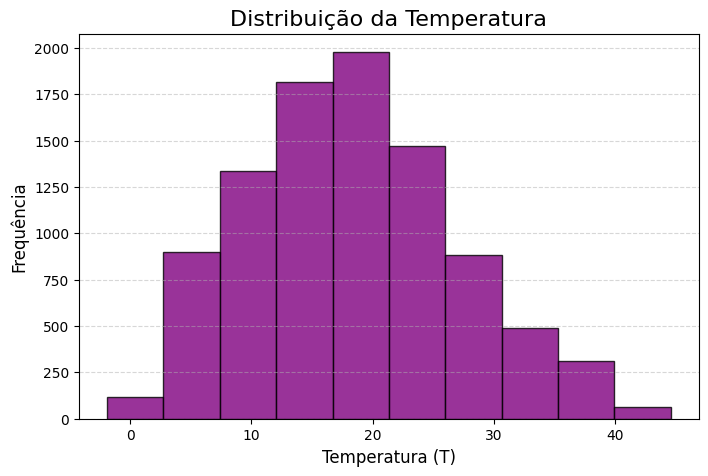

In [10]:
# @title
# ============================================================
# HISTOGRAMA DA TEMPERATURA (T)
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    df["T"].dropna(),
    bins=10,
    color="purple",
    edgecolor="black",
    alpha=0.8
)

plt.title(
    "Distribuição da Temperatura",
    fontsize=16
)

plt.xlabel(
    "Temperatura (T)",
    fontsize=12
)

plt.ylabel(
    "Frequência",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()

**Umidade Relativa**

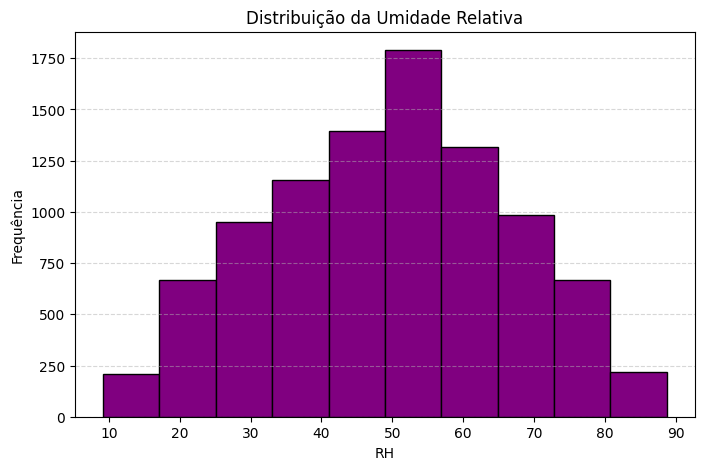

In [11]:
# @title
plt.figure(figsize=(8,5))

plt.hist(
    df["RH"].dropna(),
    bins=10,
    color="purple",
    edgecolor="black"
)

plt.title("Distribuição da Umidade Relativa")
plt.xlabel("RH")
plt.ylabel("Frequência")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()



**Umidade absoluta**

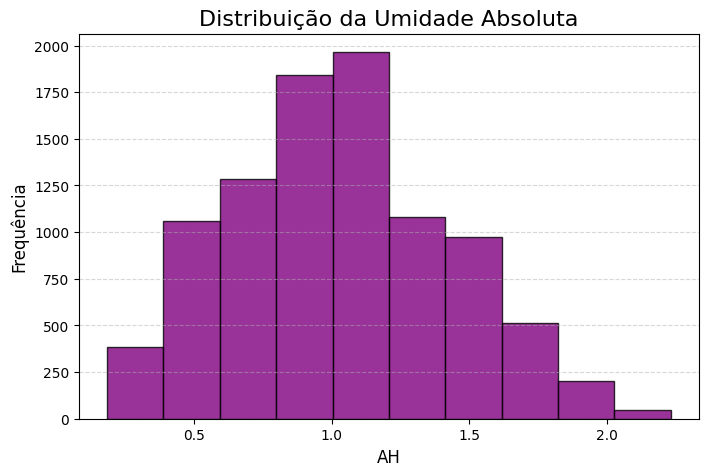

In [12]:
# @title
plt.figure(figsize=(8,5))

plt.hist(
    df["AH"].dropna(),
    bins=10,
    color="purple",
    edgecolor="black",
    alpha=0.8
)

plt.title(
    "Distribuição da Umidade Absoluta",
    fontsize=16
)

plt.xlabel(
    "AH",
    fontsize=12
)

plt.ylabel(
    "Frequência",
    fontsize=12
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

 **CO(GT)**

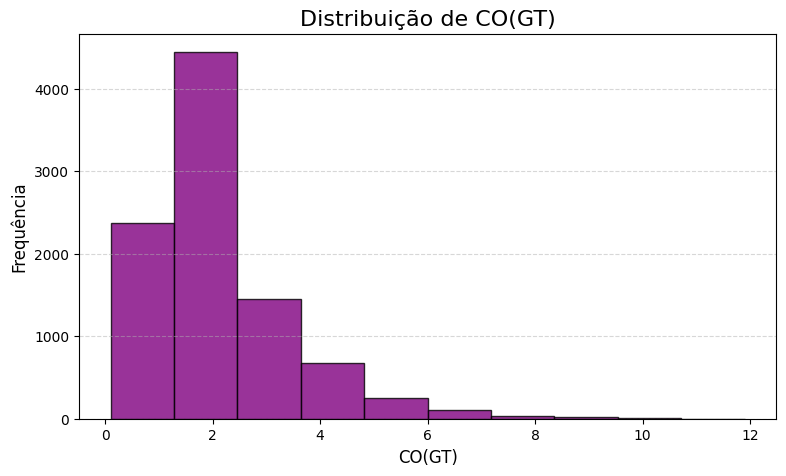

In [13]:
# @title
dados = df["CO(GT)"]

dados = dados[dados < 15]

plt.figure(figsize=(9,5))

plt.hist(
    dados,
    bins=10,
    color="purple",
    edgecolor="black",
    alpha=0.8
)

plt.title(
    "Distribuição de CO(GT)",
    fontsize=16
)

plt.xlabel(
    "CO(GT)",
    fontsize=12
)

plt.ylabel(
    "Frequência",
    fontsize=12
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

**NOx(GT)**

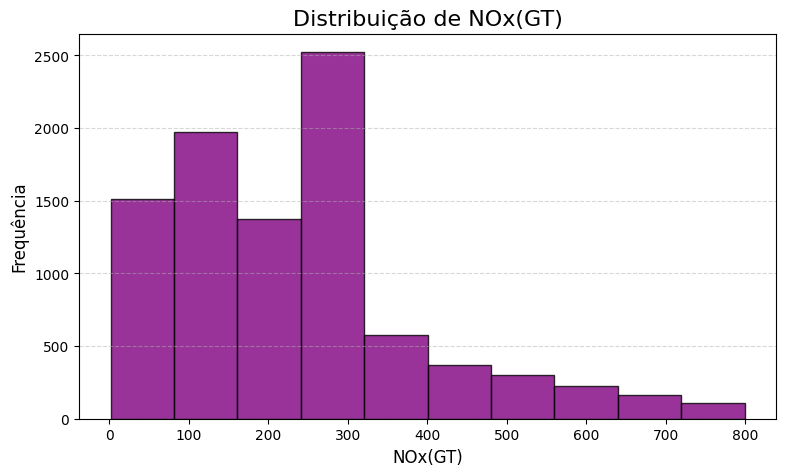

In [14]:
# @title
dados = df["NOx(GT)"]

# filtro apenas para melhorar a visualização
dados = dados[dados < 800]

plt.figure(figsize=(9,5))

plt.hist(
    dados,
    bins=10,
    color="purple",
    edgecolor="black",
    alpha=0.8
)

plt.title(
    "Distribuição de NOx(GT)",
    fontsize=16
)

plt.xlabel(
    "NOx(GT)",
    fontsize=12
)

plt.ylabel(
    "Frequência",
    fontsize=12
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

**NO2**

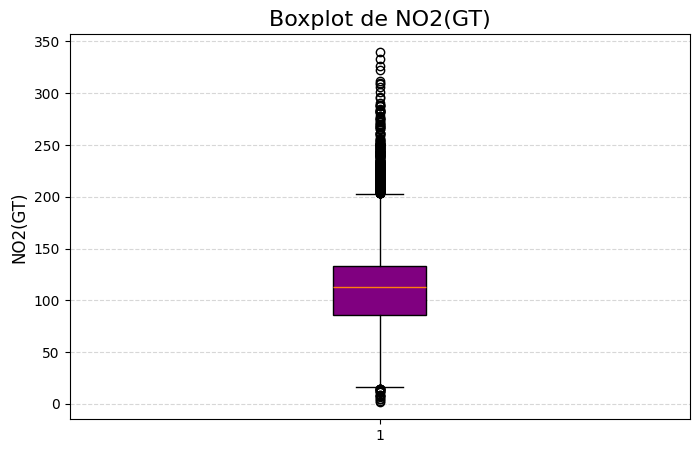

In [15]:
# @title
plt.figure(figsize=(8,5))

box = plt.boxplot(
    df["NO2(GT)"].dropna(),
    patch_artist=True
)

for caixa in box["boxes"]:
    caixa.set(facecolor="purple")

plt.title(
    "Boxplot de NO2(GT)",
    fontsize=16
)

plt.ylabel(
    "NO2(GT)",
    fontsize=12
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## 6. Análise Bivariada e Multivariada

Nesta etapa, as hipóteses exploratórias são investigadas por meio da comparação entre variáveis climáticas, temporais, poluentes e respostas dos sensores. Cada análise é acompanhada por uma síntese das evidências observadas nos dados.


### 6.1 H1 — Temperatura e poluição

**Hipótese:** temperaturas mais baixas estão associadas a maiores concentrações de poluentes atmosféricos.

Para investigar essa hipótese, as observações são agrupadas em quatro faixas de temperatura e são comparadas as concentrações médias de `CO(GT)`, `NOx(GT)` e `NO2(GT)`.


In [16]:
df_h1 = df.copy()

df_h1["Faixa_Temperatura"] = pd.cut(
    df_h1["T"],
    bins=4,
    labels=["Muito baixa", "Baixa", "Moderada", "Alta"]
)

media_por_temperatura = (
    df_h1
    .groupby("Faixa_Temperatura", observed=True)[
        ["CO(GT)", "NOx(GT)", "NO2(GT)"]
    ]
    .mean()
)

media_por_temperatura.round(2)

,CO(GT),NOx(GT),NO2(GT)
Faixa_Temperatura,,,
Muito baixa,1.98,302.71,133.13
Baixa,2.24,267.70,111.29
Moderada,2.15,199.13,104.14
Alta,1.99,147.99,111.78


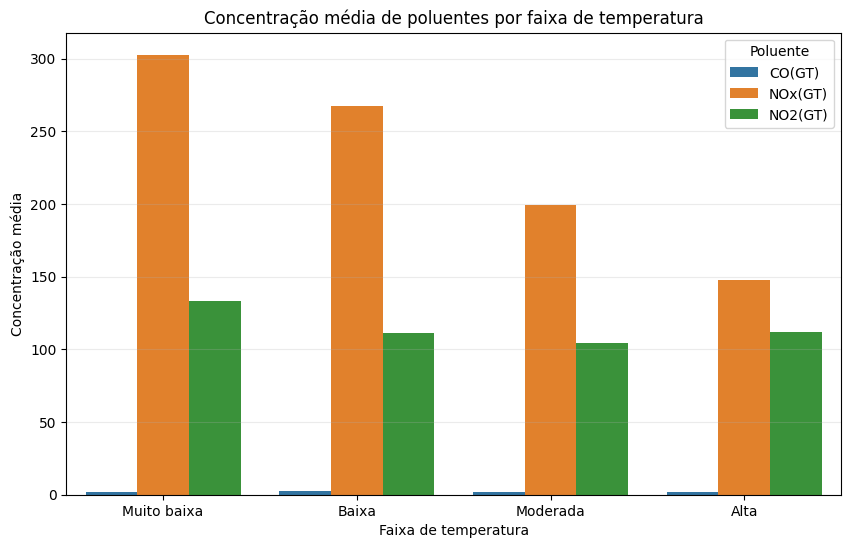

In [17]:
dados_grafico = (
    media_por_temperatura
    .reset_index()
    .melt(
        id_vars="Faixa_Temperatura",
        var_name="Poluente",
        value_name="Concentração média"
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=dados_grafico,
    x="Faixa_Temperatura",
    y="Concentração média",
    hue="Poluente"
)

plt.title("Concentração média de poluentes por faixa de temperatura")
plt.xlabel("Faixa de temperatura")
plt.ylabel("Concentração média")
plt.grid(axis="y", alpha=0.25)

plt.show()

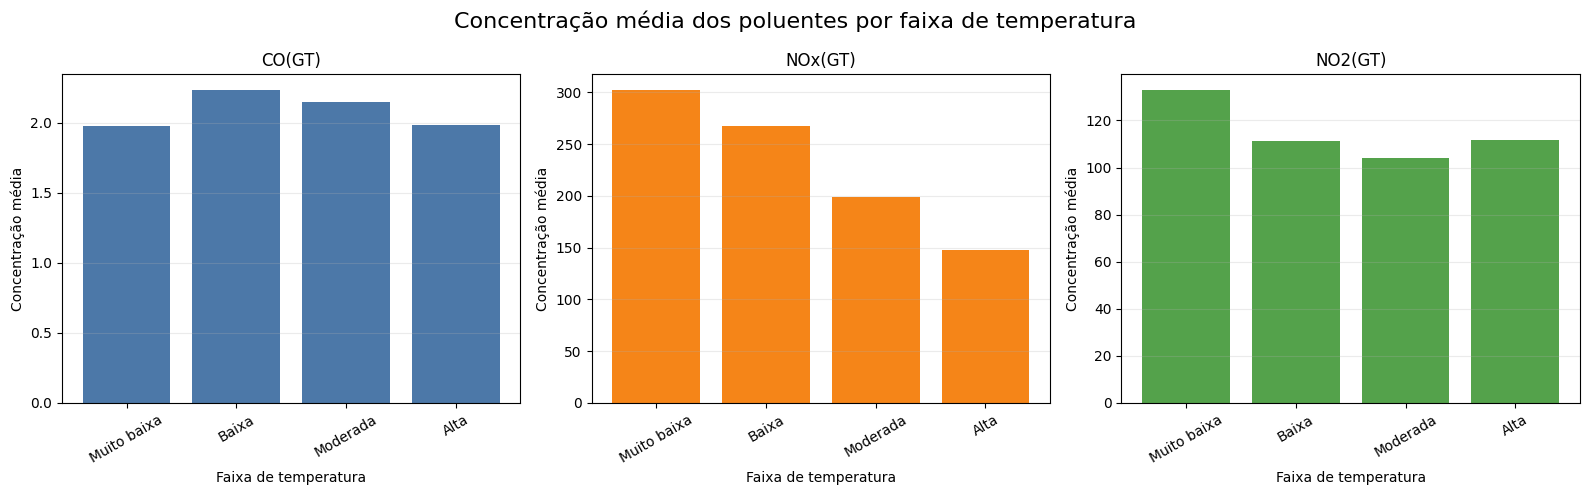

In [38]:
# Padronização das cores dos poluentes
cores = {
    "CO(GT)": "#4C78A8",   # Azul
    "NOx(GT)": "#F58518",  # Laranja
    "NO2(GT)": "#54A24B"   # Verde
}

poluentes = ["CO(GT)", "NOx(GT)", "NO2(GT)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, poluente in zip(axes, poluentes):

    ax.bar(
        media_por_temperatura.index.astype(str),
        media_por_temperatura[poluente],
        color=cores[poluente]
    )

    ax.set_title(poluente)
    ax.set_xlabel("Faixa de temperatura")
    ax.set_ylabel("Concentração média")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)

plt.suptitle(
    "Concentração média dos poluentes por faixa de temperatura",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 6.2 H2 — Umidade e poluição

**Hipótese:** níveis mais elevados de umidade estão associados a maiores concentrações de gases poluentes.

A umidade relativa (`RH`) é dividida em quatro faixas e as concentrações médias dos três poluentes são comparadas entre elas.


In [19]:
df_h2 = df.copy()

df_h2["Faixa_Umidade"] = pd.cut(
    df_h2["RH"],
    bins=4,
    labels=["Muito baixa", "Baixa", "Moderada", "Alta"]
)

df_h2[["RH", "Faixa_Umidade"]].head()

,RH,Faixa_Umidade
0,48.9,Baixa
1,47.7,Baixa
2,54.0,Moderada
3,60.0,Moderada
4,59.6,Moderada


In [20]:
media_por_umidade = (
    df_h2
    .groupby("Faixa_Umidade", observed=True)[
        ["CO(GT)", "NOx(GT)", "NO2(GT)"]
    ]
    .mean()
)

media_por_umidade.round(2)

,CO(GT),NOx(GT),NO2(GT)
Faixa_Umidade,,,
Muito baixa,2.10,192.04,120.18
Baixa,2.06,217.14,113.93
Moderada,2.22,268.55,110.77
Alta,2.23,311.24,110.41


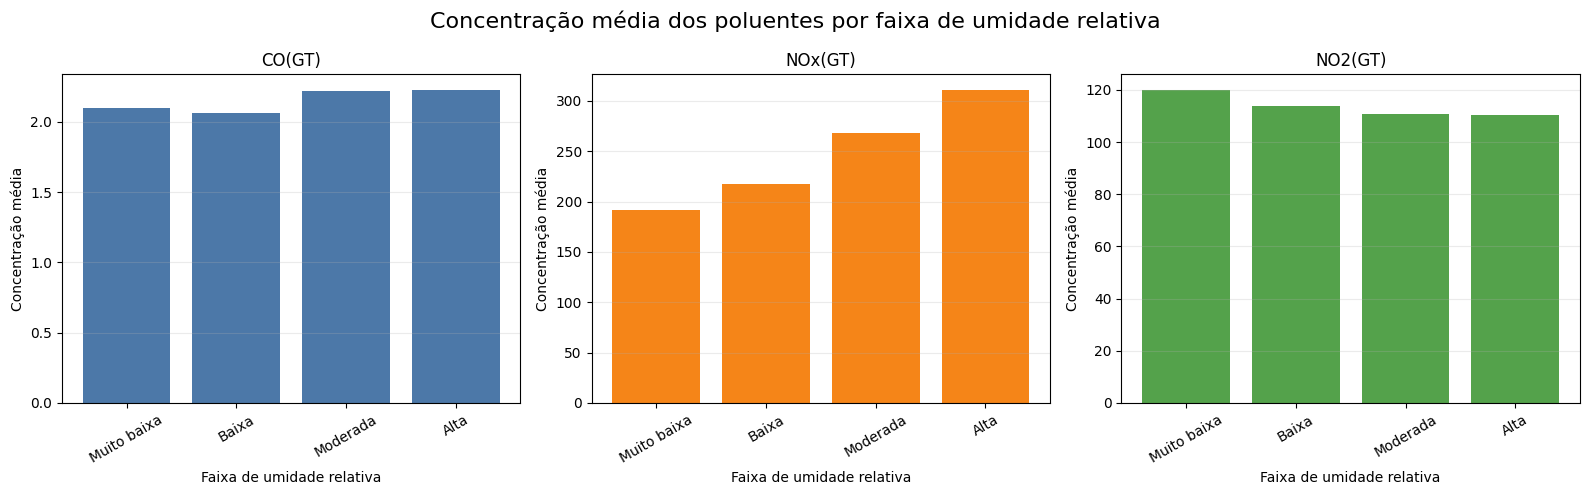

In [21]:

cores = {
    "CO(GT)": "#4C78A8",   # azul
    "NOx(GT)": "#F58518",  # laranja
    "NO2(GT)": "#54A24B"   # verde
}

poluentes = ["CO(GT)", "NOx(GT)", "NO2(GT)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, poluente in zip(axes, poluentes):

    ax.bar(
        media_por_umidade.index.astype(str),
        media_por_umidade[poluente],
        color=cores[poluente]
    )

    ax.set_title(poluente)
    ax.set_xlabel("Faixa de umidade relativa")
    ax.set_ylabel("Concentração média")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)

plt.suptitle(
    "Concentração média dos poluentes por faixa de umidade relativa",
    fontsize=16
)

plt.tight_layout()
plt.show()

#### Evidências e resultado da H2

O `NOx(GT)` apresentou crescimento progressivo, passando de **192,04** na faixa de umidade muito baixa para **311,24** na faixa alta. O `CO(GT)` apresentou pequena elevação, de **2,10** para **2,23**, enquanto o `NO2(GT)` diminuiu de **120,18** para **110,41**.

Dessa forma, **a H2 é parcialmente apoiada pelos dados**. A associação com maior umidade é clara para `NOx(GT)`, discreta para `CO(GT)` e não é observada para `NO2(GT)`. Isso não permite concluir que a umidade cause menor dispersão atmosférica; mostra apenas a associação observada no conjunto analisado.


### 6.3 H3 — Períodos frios e óxidos de nitrogênio

**Hipótese:** períodos de menor temperatura apresentam maiores concentrações de `NOx(GT)` e `NO2(GT)`.

Como aprofundamento da H1, os registros são divididos usando a mediana da temperatura: **frio** (`T ≤ 18,30`) e **mais quente** (`T > 18,30`).


In [22]:
df_h3 = df.copy()

temperatura_mediana = df_h3["T"].median()

df_h3["Periodo"] = np.where(
    df_h3["T"] <= temperatura_mediana,
    "Frio",
    "Mais quente"
)

print(f"Temperatura mediana: {temperatura_mediana:.2f}")

df_h3[["T", "Periodo"]].head()

Temperatura mediana: 18.30


,T,Periodo
0,13.6,Frio
1,13.3,Frio
2,11.9,Frio
3,11.0,Frio
4,11.2,Frio


In [23]:
media_periodos = (
    df_h3
    .groupby("Periodo")[
        ["NOx(GT)", "NO2(GT)"]
    ]
    .mean()
)

media_periodos.round(2)

,NOx(GT),NO2(GT)
Periodo,,
Frio,283.47,119.91
Mais quente,209.91,106.20


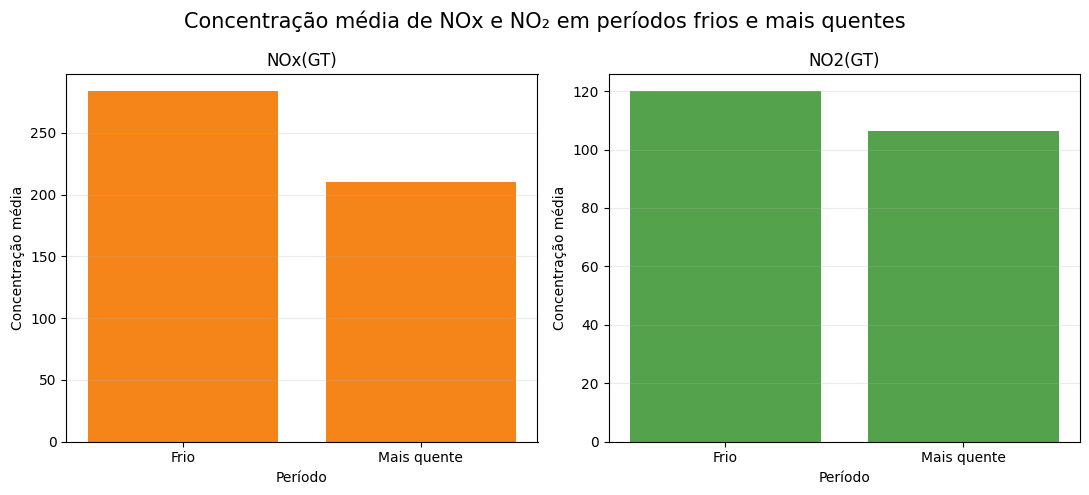

In [24]:
cores = {
    "NOx(GT)": "#F58518",
    "NO2(GT)": "#54A24B"
}

poluentes = ["NOx(GT)", "NO2(GT)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, poluente in zip(axes, poluentes):

    ax.bar(
        media_periodos.index,
        media_periodos[poluente],
        color=cores[poluente]
    )

    ax.set_title(poluente)
    ax.set_xlabel("Período")
    ax.set_ylabel("Concentração média")
    ax.grid(axis="y", alpha=0.25)

plt.suptitle(
    "Concentração média de NOx e NO₂ em períodos frios e mais quentes",
    fontsize=15
)

plt.tight_layout()
plt.show()

#### Evidências e resultado da H3

Nos períodos frios, a média de `NOx(GT)` foi **283,47**, contra **209,91** nos períodos mais quentes. Para `NO2(GT)`, as médias foram **119,91** e **106,20**, respectivamente.

Portanto, **a H3 é apoiada pelos dados**: ambos apresentaram concentrações médias superiores nos períodos de menor temperatura, com diferença especialmente acentuada para `NOx(GT)`.


### 6.4 H4 — Padrões ao longo do dia

**Hipótese:** as concentrações de `CO(GT)`, `NOx(GT)` e `NO2(GT)` apresentam variações de acordo com o horário do dia.

A hora é extraída de `Datetime` e são calculadas as concentrações médias para cada uma das 24 horas.


In [25]:
df_h4 = df.copy()

df_h4["Hora"] = df_h4["Datetime"].dt.hour

df_h4[["Datetime", "Hora"]].head()

,Datetime,Hora
0,2004-03-10 18:00:00,18
1,2004-03-10 19:00:00,19
2,2004-03-10 20:00:00,20
3,2004-03-10 21:00:00,21
4,2004-03-10 22:00:00,22


In [26]:
media_por_hora = (
    df_h4
    .groupby("Hora")[
        ["CO(GT)", "NOx(GT)", "NO2(GT)"]
    ]
    .mean()
)

media_por_hora.round(2)

,CO(GT),NOx(GT),NO2(GT)
Hora,,,
0,1.84,198.24,104.67
1,1.59,170.19,93.75
2,1.29,137.66,81.04
3,1.14,238.08,110.89
4,1.51,105.80,66.72
5,0.98,110.20,67.43
6,1.14,143.10,77.68
7,1.87,227.82,97.35
8,2.70,329.42,119.97


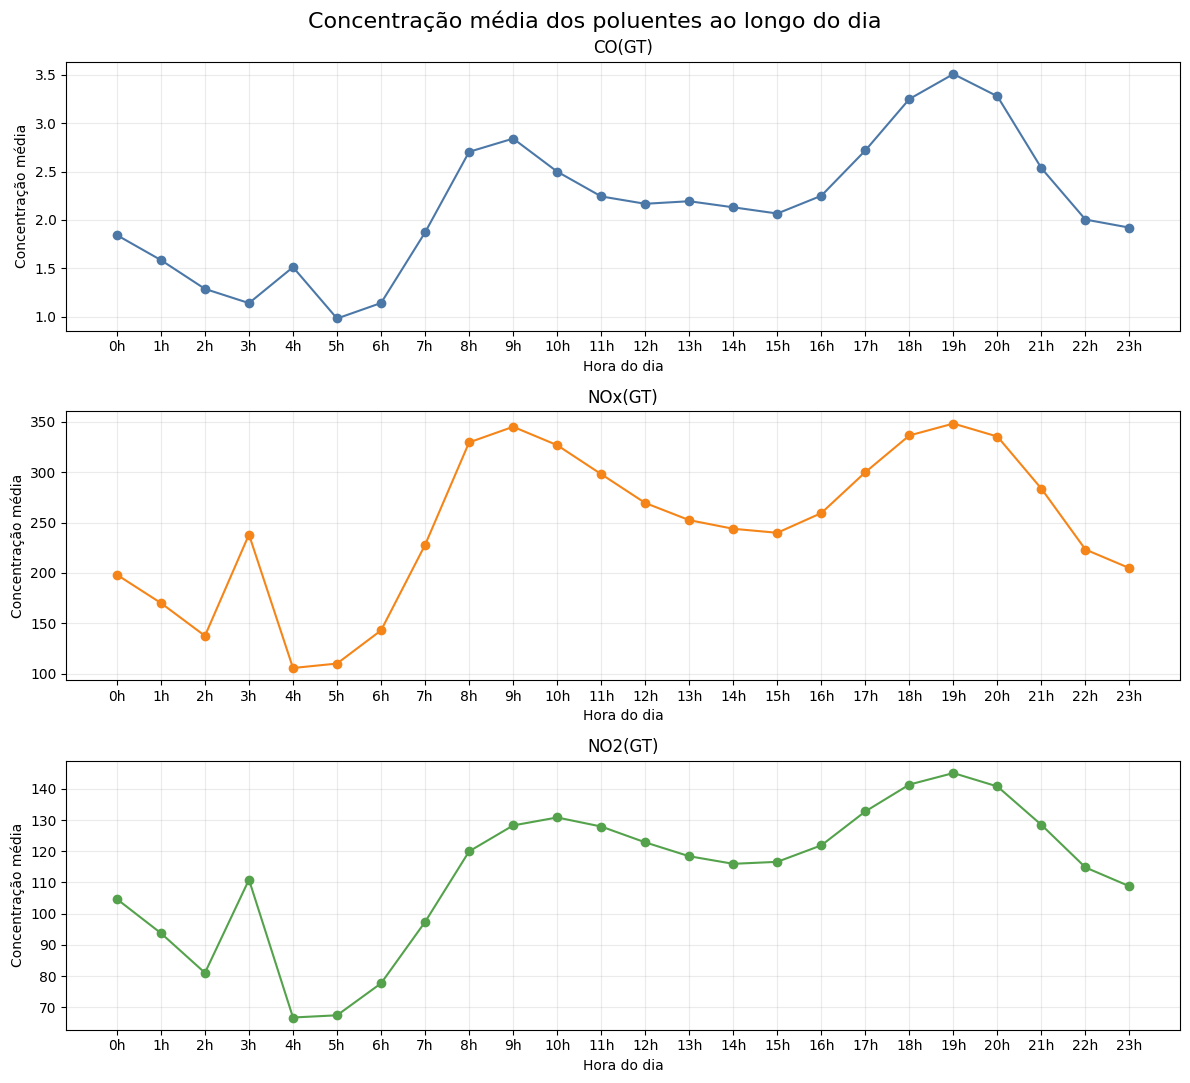

In [27]:
cores = {
    "CO(GT)": "#4C78A8",
    "NOx(GT)": "#F58518",
    "NO2(GT)": "#54A24B"
}

poluentes = ["CO(GT)", "NOx(GT)", "NO2(GT)"]

fig, axes = plt.subplots(3, 1, figsize=(12, 11))

for ax, poluente in zip(axes, poluentes):

    ax.plot(
        media_por_hora.index,
        media_por_hora[poluente],
        marker="o",
        color=cores[poluente]
    )

    ax.set_title(poluente)
    ax.set_xlabel("Hora do dia")
    ax.set_ylabel("Concentração média")

    # Mostrar todas as 24 horas
    ax.set_xticks(range(24))
    ax.set_xticklabels(
        [f"{hora}h" for hora in range(24)]
    )

    ax.grid(alpha=0.25)

plt.suptitle(
    "Concentração média dos poluentes ao longo do dia",
    fontsize=16
)

plt.tight_layout()
plt.show()

#### Evidências e resultado da H4

O `CO(GT)` atingiu **2,84** às 9h e seu maior valor médio às 19h (**3,51**). O `NOx(GT)` chegou a **344,90** às 9h e **348,09** às 19h. O `NO2(GT)` apresentou **128,28** às 9h e pico médio de **145,06** às 19h.

Assim, **a H4 é apoiada pelos dados**: os três poluentes variam de maneira expressiva conforme o horário. Os picos não podem ser atribuídos diretamente a trânsito ou outras fontes específicas sem dados adicionais.


### 6.5 H5 — Relação entre NOx e NO₂

**Hipótese:** `NOx(GT)` e `NO2(GT)` apresentam comportamento semelhante ao longo do período analisado.

As médias mensais são comparadas em relação às respectivas médias gerais, permitindo observar se aumentos e reduções ocorrem em períodos semelhantes.


In [28]:
df_h5 = df.copy()

df_h5["Mes"] = (
    df_h5["Datetime"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

media_mensal_h5 = (
    df_h5
    .groupby("Mes")[["NOx(GT)", "NO2(GT)"]]
    .mean()
)

media_mensal_h5.round(2)

,NOx(GT),NO2(GT)
Mes,,
2004-03-01,147.95,103.04
2004-04-01,174.93,102.15
2004-05-01,146.62,97.06
2004-06-01,134.37,95.99
2004-07-01,131.92,104.52
2004-08-01,131.50,84.14
2004-09-01,267.66,109.98
2004-10-01,294.29,100.96
2004-11-01,408.92,121.72


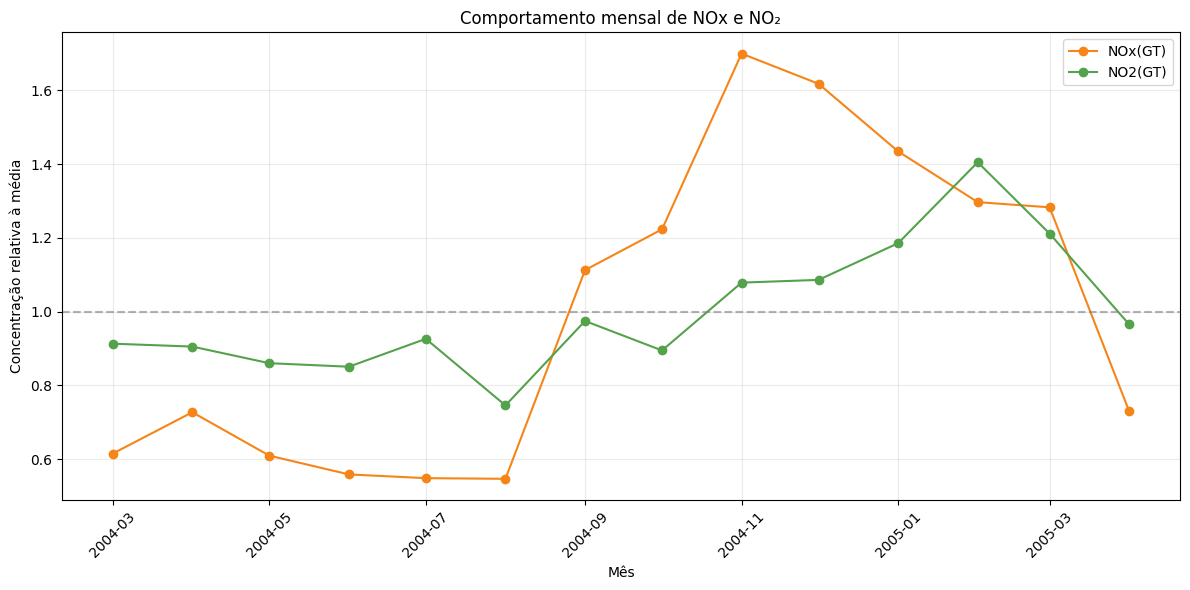

In [29]:
comparacao_h5 = media_mensal_h5.copy()

comparacao_h5["NOx_relativo"] = (
    comparacao_h5["NOx(GT)"] /
    comparacao_h5["NOx(GT)"].mean()
)

comparacao_h5["NO2_relativo"] = (
    comparacao_h5["NO2(GT)"] /
    comparacao_h5["NO2(GT)"].mean()
)
plt.figure(figsize=(12, 6))

plt.plot(
    comparacao_h5.index,
    comparacao_h5["NOx_relativo"],
    marker="o",
    color="#F58518",
    label="NOx(GT)"
)

plt.plot(
    comparacao_h5.index,
    comparacao_h5["NO2_relativo"],
    marker="o",
    color="#54A24B",
    label="NO2(GT)"
)

plt.axhline(
    y=1,
    linestyle="--",
    color="gray",
    alpha=0.6
)

plt.title("Comportamento mensal de NOx e NO₂")
plt.xlabel("Mês")
plt.ylabel("Concentração relativa à média")

plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

#### Evidências e resultado da H5

O `NOx(GT)` cresce de forma acentuada no segundo semestre de 2004 e atinge sua maior média mensal em **novembro de 2004 (408,92)**. O `NO2(GT)` também se eleva nos meses finais, mas seu maior valor ocorre em **fevereiro de 2005 (158,57)**.

Dessa forma, **a H5 é parcialmente apoiada pelos dados**: os dois poluentes apresentam movimentos temporais semelhantes em diversos momentos, porém diferem na intensidade e no momento de seus picos.


### 6.6 H6 — Sensores e medições de referência

**Hipótese:** as respostas dos sensores `PT08` apresentam comportamento associado às concentrações de referência dos poluentes analisados.

As médias mensais das medições de referência são comparadas às respostas dos sensores correspondentes em escala relativa.


In [30]:
sensores_pt08 = [
    coluna for coluna in df.columns
    if coluna.startswith("PT08")
]

sensores_pt08

['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']

In [31]:
pares_sensores = {
    "CO(GT)": "PT08.S1(CO)",
    "NOx(GT)": "PT08.S3(NOx)",
    "NO2(GT)": "PT08.S4(NO2)"
}

In [32]:
df_h6 = df.copy()

df_h6["Mes"] = (
    df_h6["Datetime"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

variaveis_h6 = [
    "CO(GT)", "PT08.S1(CO)",
    "NOx(GT)", "PT08.S3(NOx)",
    "NO2(GT)", "PT08.S4(NO2)"
]

media_mensal_h6 = (
    df_h6
    .groupby("Mes")[variaveis_h6]
    .mean()
)

media_mensal_h6.round(2)

,CO(GT),PT08.S1(CO),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2)
Mes,,,,,,
2004-03-01,2.29,1222.82,147.95,1029.17,103.04,1572.07
2004-04-01,2.26,1160.49,174.93,931.87,102.15,1604.95
2004-05-01,1.98,1077.10,146.62,945.39,97.06,1598.38
2004-06-01,1.93,1024.96,134.37,897.04,95.99,1708.33
2004-07-01,1.88,1046.51,131.92,804.93,104.52,1643.57
2004-08-01,1.59,988.88,131.50,835.83,84.14,1572.73
2004-09-01,2.16,1082.02,267.66,811.04,109.98,1544.47
2004-10-01,2.45,1184.80,294.29,688.34,100.96,1636.71
2004-11-01,2.66,1132.15,408.92,789.88,121.72,1372.23


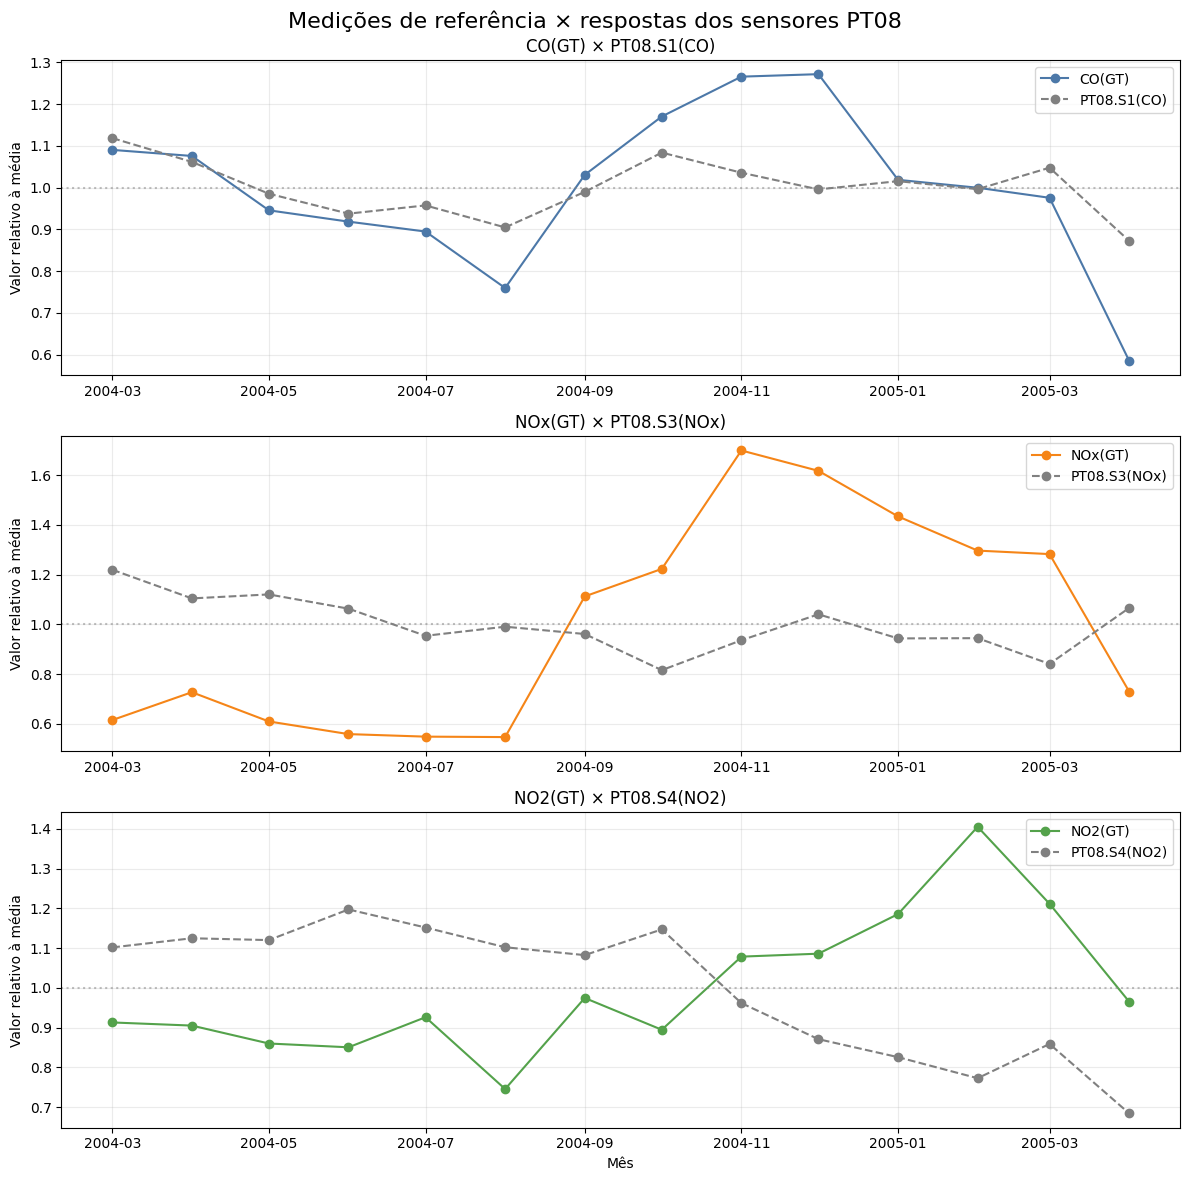

In [33]:
comparacao_h6 = media_mensal_h6.copy()

for coluna in variaveis_h6:
    comparacao_h6[coluna] = (
        comparacao_h6[coluna] /
        comparacao_h6[coluna].mean()
    )
    cores = {
    "CO(GT)": "#4C78A8",
    "NOx(GT)": "#F58518",
    "NO2(GT)": "#54A24B"
}

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, (poluente, sensor) in zip(
    axes,
    pares_sensores.items()
):

    ax.plot(
        comparacao_h6.index,
        comparacao_h6[poluente],
        marker="o",
        color=cores[poluente],
        label=poluente
    )

    ax.plot(
        comparacao_h6.index,
        comparacao_h6[sensor],
        marker="o",
        linestyle="--",
        color="gray",
        label=sensor
    )

    ax.axhline(
        1,
        linestyle=":",
        color="gray",
        alpha=0.5
    )

    ax.set_title(f"{poluente} × {sensor}")
    ax.set_ylabel("Valor relativo à média")
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Mês")

plt.suptitle(
    "Medições de referência × respostas dos sensores PT08",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 6.7 Análises complementares

Os gráficos e a matriz de correlação a seguir complementam as hipóteses anteriores e oferecem outras formas de visualizar as relações entre temperatura, poluentes e demais variáveis numéricas.


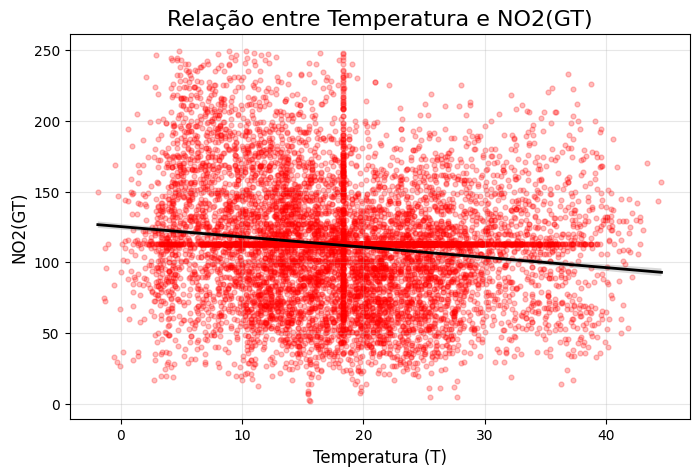

In [34]:
# @title
dados = df[df["NO2(GT)"] < 250]
plt.figure(figsize=(8,5))

sns.regplot(
    x=dados["T"],
    y=dados["NO2(GT)"],
    scatter_kws={
        "alpha":0.25,
        "color":"red",
        "s":12
    },
    line_kws={
        "color":"black",
        "linewidth":2
    }
)

plt.title(
    "Relação entre Temperatura e NO2(GT)",
    fontsize=16
)

plt.xlabel(
    "Temperatura (T)",
    fontsize=12
)

plt.ylabel(
    "NO2(GT)",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.show()

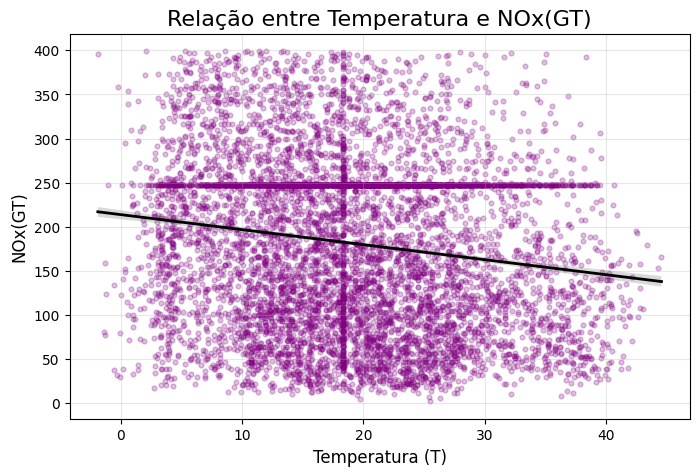

In [35]:
# @title
dados = df[df["NOx(GT)"] < 400]

plt.figure(figsize=(8,5))

sns.regplot(
    x=dados["T"],
    y=dados["NOx(GT)"],
    scatter_kws={
        "alpha":0.25,
        "color":"purple",
        "s":12
    },
    line_kws={
        "color":"black",
        "linewidth":2
    }
)

plt.title(
    "Relação entre Temperatura e NOx(GT)",
    fontsize=16
)

plt.xlabel(
    "Temperatura (T)",
    fontsize=12
)

plt.ylabel(
    "NOx(GT)",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.show()

In [36]:
# @title
correlacao = df.corr(numeric_only=True)

correlacao.round(2)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
CO(GT),1.00,0.77,0.29,0.81,0.80,0.76,-0.61,0.65,0.56,0.76,0.02,0.04,0.04
PT08.S1(CO),0.77,1.00,0.28,0.88,0.89,0.62,-0.77,0.56,0.68,0.90,0.05,0.11,0.14
NMHC(GT),0.29,0.28,1.00,0.28,0.28,0.10,-0.26,0.16,0.23,0.24,0.07,-0.05,0.04
C6H6(GT),0.81,0.88,0.28,1.00,0.98,0.62,-0.74,0.54,0.77,0.87,0.20,-0.06,0.17
PT08.S2(NMHC),0.80,0.89,0.28,0.98,1.00,0.60,-0.80,0.56,0.78,0.88,0.24,-0.09,0.19
NOx(GT),0.76,0.62,0.10,0.62,0.60,1.00,-0.56,0.76,0.21,0.69,-0.24,0.19,-0.13
PT08.S3(NOx),-0.61,-0.77,-0.26,-0.74,-0.80,-0.56,1.00,-0.57,-0.54,-0.80,-0.15,-0.06,-0.23
NO2(GT),0.65,0.56,0.16,0.54,0.56,0.76,-0.57,1.00,0.14,0.63,-0.17,-0.08,-0.29
PT08.S4(NO2),0.56,0.68,0.23,0.77,0.78,0.21,-0.54,0.14,1.00,0.59,0.56,-0.03,0.63
PT08.S5(O3),0.76,0.90,0.24,0.87,0.88,0.69,-0.80,0.63,0.59,1.00,-0.03,0.12,0.07


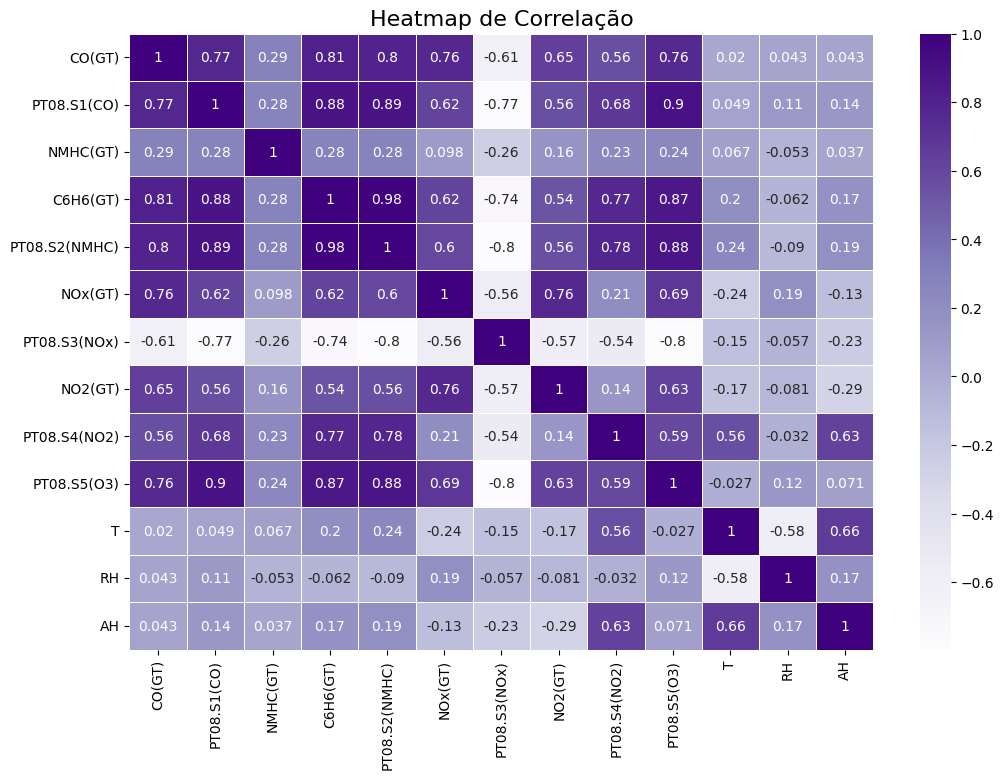

In [37]:
# @title
plt.figure(figsize=(12,8))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="Purples",
    linewidths=0.5
)

plt.title(
    "Heatmap de Correlação",
    fontsize=16
)

plt.show()

## 7. Identificação de Padrões — O que os dados nos dizem

A análise conjunta evidencia que **temperatura, umidade e horário estão associados de maneiras diferentes aos níveis de poluição**. O padrão climático mais consistente aparece nos óxidos de nitrogênio: `NOx(GT)` e `NO2(GT)` apresentaram concentrações médias maiores nos períodos frios, com destaque para o `NOx(GT)`, que também aumentou progressivamente nas faixas de maior umidade relativa. O `CO(GT)`, por outro lado, mostrou comportamento mais estável nas comparações climáticas realizadas.

Também foi identificado um padrão temporal marcante ao longo do dia. Os três poluentes apresentaram elevações durante a manhã e, sobretudo, no final da tarde e início da noite, com valores médios particularmente altos por volta das 19h. `NOx(GT)` e `NO2(GT)` demonstraram ainda tendências mensais parcialmente semelhantes, embora seus máximos tenham ocorrido em momentos diferentes.

Os dados apresentam valores extremos, especialmente para `NOx(GT)` e `NO2(GT)`, indicando observações bastante afastadas do comportamento predominante. Esses pontos devem ser interpretados com cautela: o conjunto de dados, isoladamente, não permite atribuí-los a trânsito intenso, atividade industrial ou episódios específicos de poluição.

Por fim, as respostas dos sensores `PT08` selecionados não acompanharam de maneira consistente as respectivas medições de referência na comparação mensal, sugerindo uma relação mais complexa do que uma correspondência direta e abrindo espaço para estudos futuros de calibração e validação.


## 8. Comunicação dos Resultados

Os resultados mostram que a relação entre clima e poluição não é uniforme entre os gases analisados. As evidências mais fortes foram encontradas para os óxidos de nitrogênio: períodos frios apresentaram maiores concentrações médias de `NOx(GT)` e `NO2(GT)`, enquanto a maior umidade relativa esteve associada principalmente ao aumento de `NOx(GT)`. A análise horária revelou ainda uma dinâmica temporal clara, com elevação das concentrações durante a manhã e no final da tarde/início da noite.

Em síntese, **H3 e H4 foram apoiadas pelos dados; H1, H2 e H5 receberam apoio parcial; e H6 não foi apoiada de maneira geral pela análise visual realizada**. As evidências representam associações exploratórias e não demonstram relações de causa e efeito.


### Síntese das hipóteses

| Hipótese | Resultado | Evidência principal |
|---|---|---|
| H1 — Temperatura e poluição | Parcialmente apoiada | NOx caiu de 302,71 para 147,99 entre as faixas muito baixa e alta de temperatura; CO permaneceu estável. |
| H2 — Umidade e poluição | Parcialmente apoiada | NOx subiu de 192,04 para 311,24 entre as faixas muito baixa e alta de umidade; NO₂ não acompanhou o padrão. |
| H3 — Períodos frios e NOx/NO₂ | Apoiada | NOx: 283,47 vs. 209,91; NO₂: 119,91 vs. 106,20. |
| H4 — Padrões ao longo do dia | Apoiada | Os três poluentes variaram ao longo das 24h e apresentaram valores elevados no fim da tarde/início da noite. |
| H5 — Relação entre NOx e NO₂ | Parcialmente apoiada | Tendências mensais semelhantes em parte da série, mas máximos em meses diferentes. |
| H6 — Sensores PT08 | Não apoiada pela análise visual | As respostas mensais dos sensores selecionados não acompanharam consistentemente as medições de referência. |


## 9. Conclusão

A análise exploratória permitiu compreender diferentes aspectos do comportamento da qualidade do ar no período estudado. Entre os resultados mais relevantes, destacam-se as maiores concentrações médias de `NOx(GT)` e `NO2(GT)` em períodos frios e a existência de padrões horários claros para os três principais poluentes. A umidade apresentou relação especialmente com `NOx(GT)`, enquanto `CO(GT)` mostrou comportamento mais estável nas comparações climáticas realizadas.

As análises também mostraram que `NOx(GT)` e `NO2(GT)` compartilham parte de sua dinâmica temporal, mas não se comportam de forma idêntica, e que as respostas dos sensores `PT08` selecionados não apresentaram correspondência mensal consistente com as medições de referência na abordagem utilizada.

Por se tratar de uma análise exploratória, os resultados devem ser interpretados como **associações presentes nos dados**, e não como evidências de causalidade. Como continuidade do projeto, seria possível investigar sazonalidade, dias da semana, episódios extremos, métodos alternativos de tratamento de valores ausentes e técnicas específicas de calibração ou modelagem dos sensores.
